Imports and setup

In [24]:
import spacy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Load models
nlp = spacy.load("en_core_web_lg")
model_bert = SentenceTransformer("all-MiniLM-L6-v2")

test_pairs = [
## STANDARD TEST PAIRS (from previous notebooks)
    # Direct copies and near-copies
    ("The cat sat on the mat.", "The cat sat on the mat."),           # Exact copy
    ("The cat sat on the mat.", "The cat sat on the mat"),            # No punctuation
    ("The cat sat on the mat.", "The  cat  sat  on  the  mat."),      # Extra spaces
    
    # Paraphrases with same meaning
    ("The cat sat on the mat.", "On the mat, the cat was sitting."),  # Structural change
    ("The cat sat on the mat.", "The feline rested on the rug."),     # Synonym replacement
    ("The quick brown fox jumps.", "A fast brown fox leaps."),        # Partial synonym
    
    # Different sentences
    ("The cat sat on the mat.", "The dog ran in the park."),          # Different content
    ("I love programming.", "She enjoys reading books."),             # Completely different
    ("The weather is nice today.", "It's raining outside."),          # Opposite meaning
    
    # Edge cases
    ("Short.", "Short."),                                             # Very short
    ("A B C D E F G", "A B C D E F G"),                              # Repeated words
    ("", ""),                                                         # Empty strings
## ADDITIONAL TEST PAIRS (for semantic evaluation)
    # Polysemy (word sense ambiguity) - Critical for BERT vs SpaCy
    ("He went to the bank to deposit money.", "He went to the river bank to fish."),           # Bank: financial vs. riverbank
    ("I saw the bat in the cave.", "The baseball bat is broken."),                             # Bat: animal vs. sports equipment
    ("The light is very bright.", "Can you carry this light package?"),                        # Light: brightness vs. weight
    
    # Synonymy (different words, same meaning) - Tests semantic understanding
    ("The car is fast.", "The automobile is quick."),                                          # car/automobile, fast/quick
    ("He commenced the project.", "He started the work."),                                     # commenced/started, project/work
    ("The substantial building is ornate.", "The large building is decorated."),               # substantial/large, ornate/decorated
    
    # Negation (opposite meaning) - Tests if methods catch semantic inversion
    ("The weather is good.", "The weather is bad."),                                           # Direct negation
    ("The solution is simple.", "The problem is complex."),                                    # Opposite adjectives
    ("I like this movie.", "I dislike this movie."),                                           # Explicit negation
    
    # Semantic similarity without word overlap - Pure meaning test
    ("A man walks down the street.", "A person strolls along the road."),                      # Very few shared words, similar meaning
    ("The student studied the textbook.", "The pupil learned from the book."),                 # Different words, same semantic content
    
    # Partial overlap (high word similarity, low semantic similarity)
    ("The bank is on the river.", "The bank account is overdrawn."),                           # "bank" is only shared word; different meanings
    ("I read the book last night.", "The book was read by many people."),                      # Same key words (book, read) but different focus/meaning
    
    # Length variation (tests robustness to sentence length)
    ("Cat sat.", "The cat sat on the mat for hours and hours."),                               # Very different lengths, similar core meaning
    ("Go.", "You should go to the store and buy milk immediately."),                           # Minimal vs. detailed
    
    # Metaphor/Figurative language
    ("Time is money.", "Time has value."),                                                     # Metaphor vs. literal
    ("The world is a stage.", "Life is like a theater performance."),                          # Figurative expressions
]

print(f"Loaded {len(test_pairs)} test pairs")

Loaded 29 test pairs


## Method 1: SIF smooth inverse frequency
Weighting word vectors based on frequency, emphasize information-dense words

In [25]:
def sentence_similarity_sif(sent1, sent2, a=0.001):
    """Compute similarity using SIF-weighted word vectors."""
    def get_weighted_vector(text):
        doc = nlp(text)
        vectors = []
        weights = []
        
        for token in doc:
            if token.has_vector and token.is_alpha and not token.is_stop:
                prob = np.exp(token.prob) if token.prob > -19 else 1e-6
                weight = a / (a + prob)
                vectors.append(token.vector)
                weights.append(weight)
        
        if not vectors:
            return np.zeros(nlp.vocab.vectors_length)
        
        return np.average(vectors, axis=0, weights=weights)

    v1 = get_weighted_vector(sent1)
    v2 = get_weighted_vector(sent2)
    
    return cosine_similarity(v1.reshape(1, -1), v2.reshape(1, -1))[0][0]

In [26]:
s1 = "The cat ate the food."
s2 = "The feline devoured the sustenance."

print(f"SIF Similarity: {sentence_similarity_sif(s1, s2):.3f}")

SIF Similarity: 0.609


## Method 2: BERT - Transformer Embedding
Use contectual embeddings to resolve polysemy issues

In [27]:
def sentence_similarity_bert(sent1, sent2):
    """Compute similarity using SBERT contextual embeddings."""
    embeddings = model_bert.encode([sent1, sent2])
    return cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]

In [28]:
sent_a = "He went to the bank to deposit money."
sent_b = "He went to the river bank to fish."
sent_c = "He visited the financial institution."

print(f"Bank (Money) vs Bank (River): {sentence_similarity_bert(sent_a, sent_b):.3f}")
print(f"Bank (Money) vs Institution:  {sentence_similarity_bert(sent_a, sent_c):.3f}")


Bank (Money) vs Bank (River): 0.590
Bank (Money) vs Institution:  0.641


### Semantic Evaluation
Comparing simple average baseline, SIF and BERT

In [ ]:
def sentence_similarity_avg(s1, s2):
    d1, d2 = nlp(s1), nlp(s2)
    v1 = np.mean([t.vector for t in d1 if t.has_vector], axis=0) if len(d1) > 0 else np.zeros(300)
    v2 = np.mean([t.vector for t in d2 if t.has_vector], axis=0) if len(d2) > 0 else np.zeros(300)
    return cosine_similarity([v1], [v2])[0][0]

def evaluate_semantic_methods(pairs):
    """Evaluate semantic methods on test pairs without verbose text output."""
    methods = {
        "Spacy Avg": sentence_similarity_avg,
        "Spacy SIF": sentence_similarity_sif,
        "BERT": sentence_similarity_bert
    }

    rows = []
    for i, (sent1, sent2) in enumerate(pairs):
        row = {"pair_id": i, "sentence_1": sent1, "sentence_2": sent2}
        for name, func in methods.items():
            score = func(sent1, sent2)
            row[name] = score
        rows.append(row)

    return pd.DataFrame(rows)

results_df = evaluate_semantic_methods(test_pairs)

# Display only the scores (not sentences) for a cleaner comparison
print("Semantic Method Results:")
print("=" * 70)
display(results_df[["pair_id", "Spacy Avg", "Spacy SIF", "BERT"]].round(3))


Semantic Method Results:


,pair_id,Spacy Avg,Spacy SIF,BERT
0,0,1.000,1.000,1.000
1,1,0.984,1.000,0.995
2,2,1.000,1.000,1.000
3,3,0.965,0.954,0.930
4,4,0.901,0.696,0.549
5,5,0.942,0.930,0.945
6,6,0.857,0.642,0.067
7,7,0.702,0.529,0.154
8,8,0.845,0.603,0.468
9,9,1.000,1.000,1.000


### Visualization

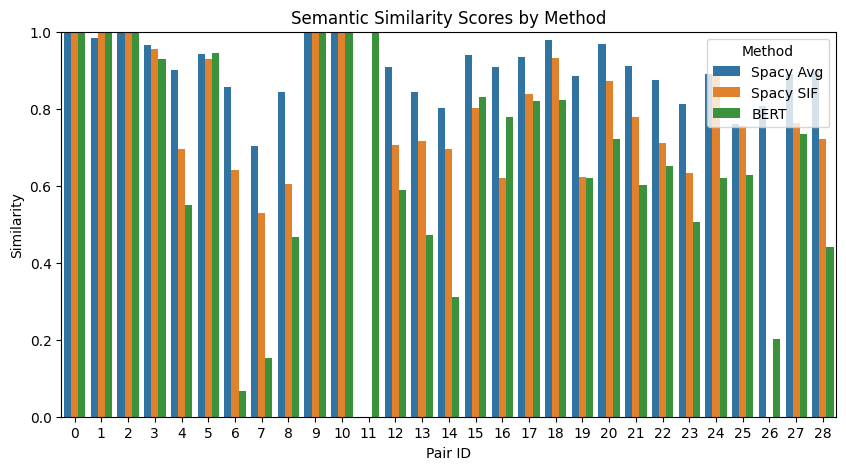

In [30]:
plt.figure(figsize=(10, 5))
melted = results_df.melt(
    id_vars=["pair_id"], 
    value_vars=["Spacy Avg", "Spacy SIF", "BERT"], 
    var_name="Method", 
    value_name="Similarity"
)

sns.barplot(data=melted, x="pair_id", y="Similarity", hue="Method")
plt.title("Semantic Similarity Scores by Method")
plt.xlabel("Pair ID")
plt.ylabel("Similarity")
plt.ylim(0, 1)
plt.show()


Category Comparison

In [35]:
# Manually assign categories to each pair
categories = [
    # Direct copies (0-2)
    'Exact Copy', 'Exact Copy', 'Exact Copy',
    # Paraphrases (3-5)
    'Paraphrase', 'Paraphrase', 'Paraphrase',
    # Different (6-8)
    'Different', 'Different', 'Different',
    # Edge cases (9-11)
    'Edge Case', 'Edge Case', 'Edge Case',
    # Polysemy (12-14)
    'Polysemy', 'Polysemy', 'Polysemy',
    # Synonymy (15-17)
    'Synonymy', 'Synonymy', 'Synonymy',
    # Negation (18-20)
    'Negation', 'Negation', 'Negation',
    # Semantic Similarity (21-22)
    'Semantic Sim', 'Semantic Sim',
    # Partial Overlap (23-24)
    'Partial Overlap', 'Partial Overlap',
    # Length Variation (25-26)
    'Length Var', 'Length Var',
    # Figurative (27-28)
    'Figurative', 'Figurative'
]

results_df['category'] = categories

# Group by category and show average scores
print("\nPerformance by Category:")
print("=" * 80)
category_stats = results_df.groupby('category')[["Spacy Avg", "Spacy SIF", "BERT"]].agg(['mean', 'std']).round(3)
display(category_stats)


Performance by Category:


Spacy Avg        Spacy SIF          BERT       
                     mean    std      mean    std   mean    std
category                                                       
Different           0.801  0.086     0.591  0.057  0.229  0.211
Edge Case           0.667  0.577     0.667  0.577  1.000  0.000
Exact Copy          0.995  0.009     1.000  0.000  0.998  0.003
Figurative          0.893  0.005     0.742  0.031  0.588  0.208
Length Var          0.784  0.032     0.377  0.534  0.415  0.302
Negation            0.944  0.051     0.809  0.163  0.721  0.101
Paraphrase          0.936  0.032     0.860  0.143  0.808  0.224
Partial Overlap     0.852  0.055     0.762  0.183  0.563  0.080
Polysemy            0.851  0.053     0.706  0.011  0.457  0.140
Semantic Sim        0.893  0.027     0.746  0.048  0.628  0.035
Synonymy            0.927  0.016     0.754  0.117  0.809  0.028

Comparison Heatmap

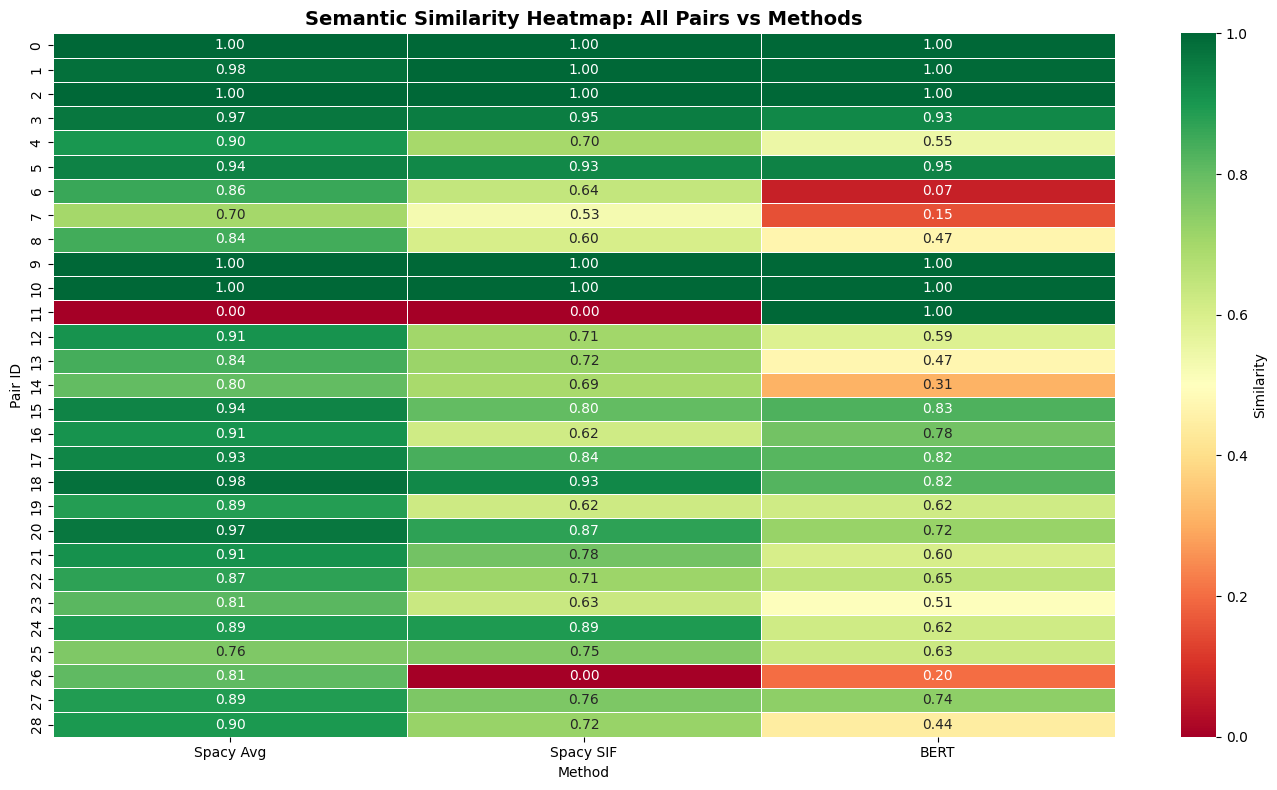

In [36]:
plt.figure(figsize=(14, 8))

# Create a pivot table for heatmap (pairs vs methods)
heatmap_data = results_df[["pair_id", "Spacy Avg", "Spacy SIF", "BERT"]].set_index("pair_id")

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', cbar_kws={'label': 'Similarity'}, 
            vmin=0, vmax=1, linewidths=0.5)
plt.title('Semantic Similarity Heatmap: All Pairs vs Methods', fontsize=14, fontweight='bold')
plt.xlabel('Method')
plt.ylabel('Pair ID')
plt.tight_layout()
plt.show()

A method with higher varience it may be less reliable while all 3 methods agreeing indicates that a pair is confident

In [31]:

method_variance = results_df[["Spacy Avg", "Spacy SIF", "BERT"]].var()
method_std = results_df[["Spacy Avg", "Spacy SIF", "BERT"]].std()

print("Method Variance (higher = more disagreement):")
print(method_variance)
print("\nMethod Std Dev:")
print(method_std)

Method Variance (higher = more disagreement):
Spacy Avg    0.033659
Spacy SIF    0.061698
BERT         0.073351
dtype: float64

Method Std Dev:
Spacy Avg    0.183464
Spacy SIF    0.248391
BERT         0.270834
dtype: float64


Two methods may give similar absoloute scores when compared but rank individual pairs differently

In [32]:
for method in ["Spacy Avg", "Spacy SIF", "BERT"]:
    results_df[f'{method}_rank'] = results_df[method].rank()

print(results_df[["pair_id", "Spacy Avg_rank", "Spacy SIF_rank", "BERT_rank"]])

    pair_id  Spacy Avg_rank  Spacy SIF_rank  BERT_rank
0         0            28.5            26.5       27.5
1         1            25.0            26.5       24.0
2         2            28.5            26.5       27.5
3         3            22.0            24.0       22.0
4         4            15.0            10.0        9.0
5         5            21.0            22.0       23.0
6         6             9.0             8.0        1.0
7         7             2.0             3.0        2.0
8         8             8.0             4.0        6.0
9         9            27.0            29.0       27.5
10       10            26.0            26.5       27.5
11       11             1.0             1.5       25.0
12       12            16.0            11.0       10.0
13       13             7.0            13.0        7.0
14       14             4.0             9.0        4.0
15       15            20.0            18.0       21.0
16       16            17.0             5.0       18.0
17       1

Test methods against the polysemy problem

In [33]:
polysemy_pairs = results_df.iloc[6:8]  # Rows 6-7 are the "bank" examples
print("Polysemy Test (Should prefer higher for synonyms, lower for different meanings):")
print(polysemy_pairs[["pair_id", "sentence_1", "Spacy Avg", "Spacy SIF", "BERT"]])

Polysemy Test (Should prefer higher for synonyms, lower for different meanings):
   pair_id               sentence_1  Spacy Avg  Spacy SIF      BERT
6        6  The cat sat on the mat.   0.856538   0.641634  0.067119
7        7      I love programming.   0.702400   0.528659  0.153708
